# AI & ML Course with BinX - Project 1: Cardiac Patient Monitoring System

## <span style="color: #309c42ff">1.1 Environment & Dataset</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We set up a reproducible Python environment using NumPy, Pandas, Matplotlib, and Seaborn. We load the Heart Disease clinical dataset from <code>../Data/heart.csv</code> to predict the binary target variable <code>HeartDisease</code> (1 = Heart Disease, 0 = Normal).

</blockquote>


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../Data/heart.csv")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
display(df.head())
df.info()


Dataset Shape: 918 rows, 12 columns



,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


## <span style="color: #309c42ff">1.2 Data Preparation</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We perform data audits using Pandas and NumPy to check for duplicates, missing values, and physiologically invalid values, and categorize columns into numerical and categorical sets.

</blockquote>


In [18]:
print("Duplicate rows count:", df.duplicated().sum())
print("\nExplicit missing values (isnull):")
print(df.isnull().sum())

zero_bp = (df['RestingBP'] == 0).sum()
zero_chol = (df['Cholesterol'] == 0).sum()

print("\n--- Physiologically Invalid Zero Values ---")
print(f"\nRestingBP zero count: {zero_bp} ({zero_bp / len(df) * 100:.2f}%)")
print(f"Cholesterol zero count: {zero_chol} ({zero_chol / len(df) * 100:.2f}%)")

categorical_features = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
numerical_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
target_variable = 'HeartDisease'

print("\nCategorical Features:", categorical_features)
print("Numerical Features:  ", numerical_features)
print("Target Variable:     ", target_variable)


Duplicate rows count: 0

Explicit missing values (isnull):
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

--- Physiologically Invalid Zero Values ---

RestingBP zero count: 1 (0.11%)
Cholesterol zero count: 172 (18.74%)

Categorical Features: ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
Numerical Features:   ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
Target Variable:      HeartDisease


## <span style="color: #309c42ff">1.3 EDA & Statistics</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We apply descriptive statistics, univariate and bivariate visualizations, IQR outlier detection, correlation analysis, pairplot scanning, and data storytelling to analyze distributions, spread, and relationships.

</blockquote>


In [19]:
desc_stats = df[numerical_features].describe().T
desc_stats['variance'] = df[numerical_features].var()
desc_stats['IQR'] = desc_stats['75%'] - desc_stats['25%']
desc_stats['median'] = df[numerical_features].median()

desc_stats = desc_stats[['count', 'mean', 'median', 'std', 'variance', 'min', '25%', '75%', 'IQR', 'max']]
print("--- Descriptive Statistics Table ---")
display(desc_stats)

target_summary = pd.DataFrame({
    'Count': df['HeartDisease'].value_counts(),
    'Percentage (%)': df['HeartDisease'].value_counts(normalize=True) * 100
})
target_summary.index = ['Heart Disease (1)', 'Normal (0)']
print("\n--- Target Class Balance ---")
display(target_summary)


--- Descriptive Statistics Table ---


,count,mean,median,std,variance,min,25%,75%,IQR,max
Age,918.0,53.510893,54.0,9.432617,88.974254,28.0,47.00,60.0,13.00,77.0
RestingBP,918.0,132.396514,130.0,18.514154,342.773903,0.0,120.00,140.0,20.00,200.0
Cholesterol,918.0,198.799564,223.0,109.384145,11964.891079,0.0,173.25,267.0,93.75,603.0
MaxHR,918.0,136.809368,138.0,25.460334,648.228614,60.0,120.00,156.0,36.00,202.0
Oldpeak,918.0,0.887364,0.6,1.066570,1.137572,-2.6,0.00,1.5,1.50,6.2



--- Target Class Balance ---


,Count,Percentage (%)
Heart Disease (1),508,55.337691
Normal (0),410,44.662309


### <span style="color: #309c42ff"> 1. Univariate Categorical distributions</span>



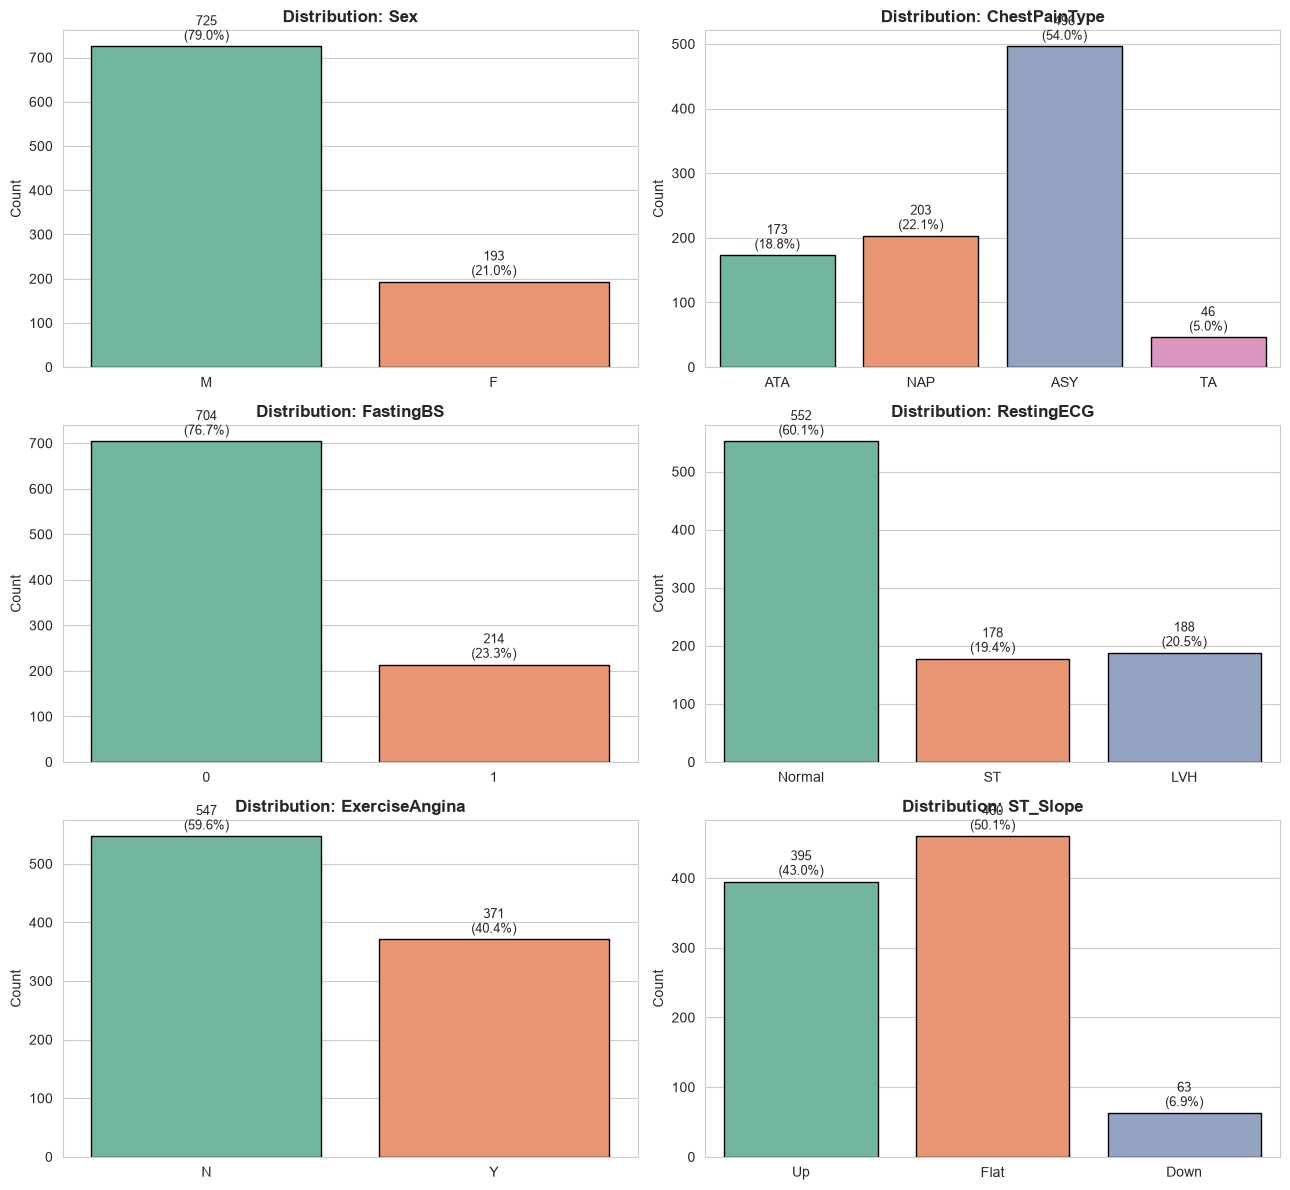

In [20]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(13, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.countplot(
        data=df, 
        x=col, 
        hue=col,
        legend=False,
        ax=axes[i], 
        palette='Set2',
        edgecolor='black'
    )
    axes[i].set_title(f'Distribution: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    
    total = len(df[col])
    for p in axes[i].patches:
        height = p.get_height()
        percentage = f'{100 * height / total:.1f}%'
        axes[i].annotate(f'{int(height)}\n({percentage})', 
                         (p.get_x() + p.get_width() / 2., height), 
                         ha='center', va='bottom', fontsize=9, xytext=(0, 2), 
                         textcoords='offset points')

plt.tight_layout()
plt.show()


### <span style="color: #309c42ff"> 2. Univariate Numerical distributions</span>



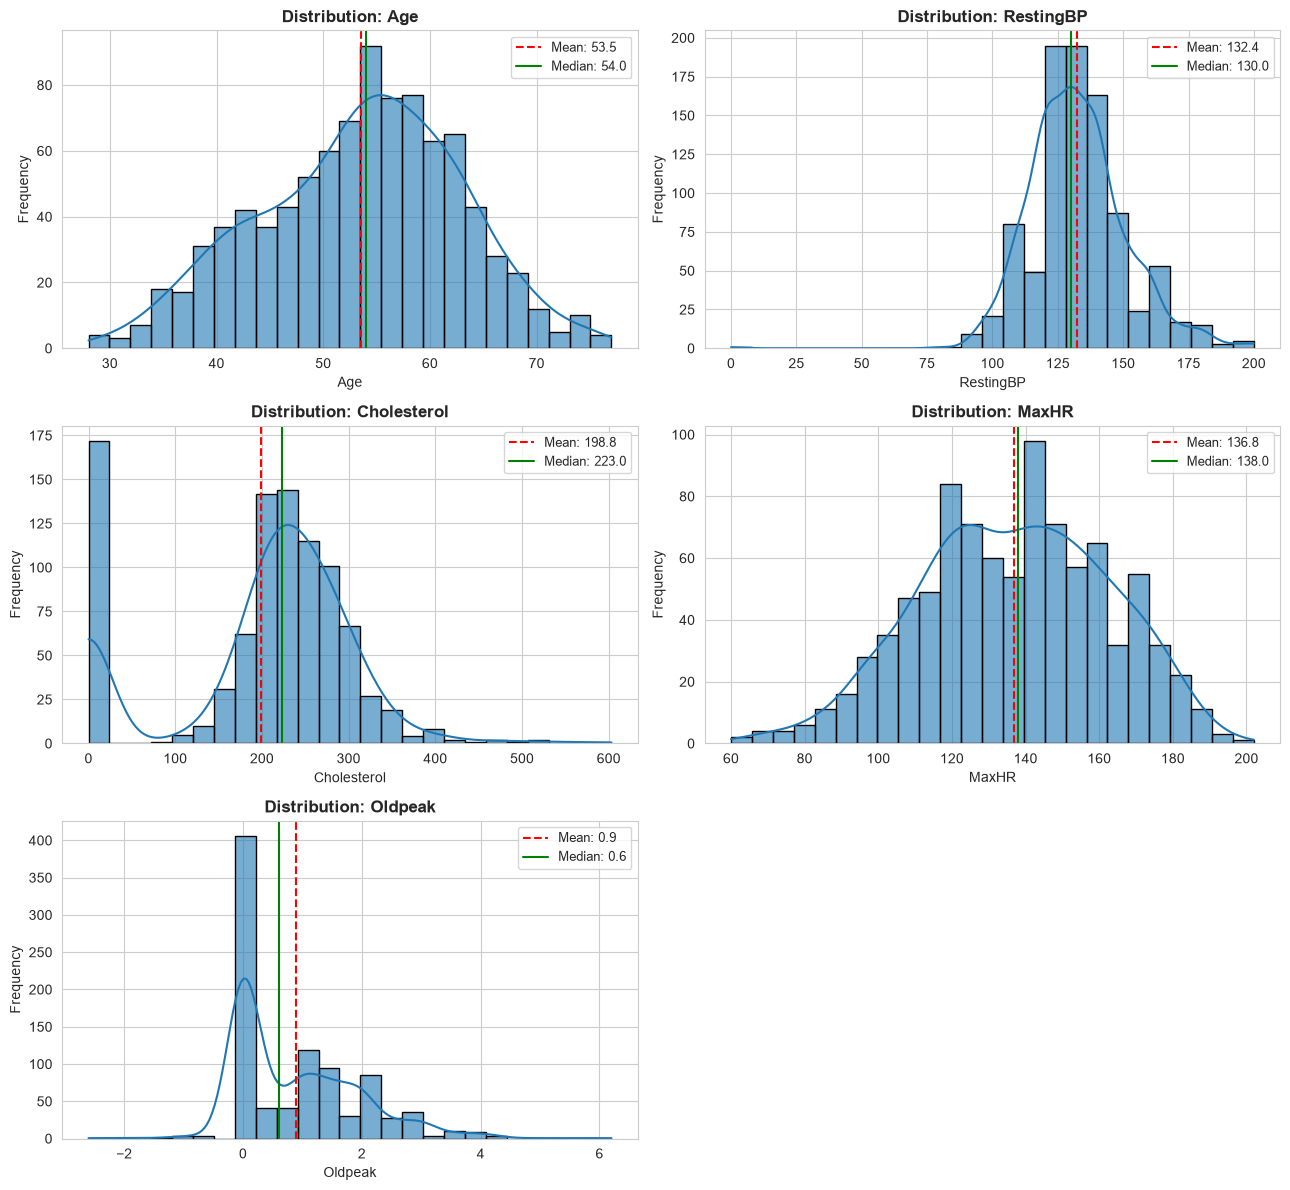

In [21]:
# Numerical distributions with mean and median lines
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(13, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.histplot(
        data=df, 
        x=col, 
        kde=True, 
        ax=axes[i], 
        color='#1f77b4',
        edgecolor='black',
        alpha=0.6,
        bins=25
    )
    axes[i].set_title(f'Distribution: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    
    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    axes[i].axvline(median_val, color='green', linestyle='-', linewidth=1.5, label=f'Median: {median_val:.1f}')
    axes[i].legend(fontsize=9)

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

### <span style="color: #309c42ff"> 3. Outlier Detection with the IQR Method</span>



In [22]:
outlier_rows = []

for col in numerical_features:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    flagged = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    count = len(flagged)
    pct = (count / len(df)) * 100
    
    outlier_rows.append({
        'Feature': col,
        'Q1 (25th)': round(q1, 2),
        'Median': round(df[col].median(), 2),
        'Q3 (75th)': round(q3, 2),
        'IQR': round(iqr, 2),
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2),
        'Outlier Count': count,
        'Outlier (%)': round(pct, 2)
    })

outlier_df = pd.DataFrame(outlier_rows)
print("--- IQR Outlier Detection Table ---")
display(outlier_df)


--- IQR Outlier Detection Table ---


,Feature,Q1 (25th),Median,Q3 (75th),IQR,Lower Bound,Upper Bound,Outlier Count,Outlier (%)
0,Age,47.00,54.0,60.0,13.00,27.50,79.50,0,0.00
1,RestingBP,120.00,130.0,140.0,20.00,90.00,170.00,28,3.05
2,Cholesterol,173.25,223.0,267.0,93.75,32.62,407.62,183,19.93
3,MaxHR,120.00,138.0,156.0,36.00,66.00,210.00,2,0.22
4,Oldpeak,0.00,0.6,1.5,1.50,-2.25,3.75,16,1.74


#### Outlier Findings & Treatment Justification:
- **`Cholesterol` (183 outliers, 19.93%):** All 183 lower-bound outliers are the value 0 mg/dl (unrecorded measurements). These represent structural missingness and will be converted to `NaN` and imputed with the median in the preprocessing pipeline. The 12 upper-bound outliers (> 459 mg/dl) represent genuine clinical hypercholesterolemia and will be retained.
- **`RestingBP` (28 outliers, 3.05%):** 1 record contains 0 mm Hg (entry error to be imputed with median). The remaining 27 records (> 170 mm Hg) represent clinically valid severe hypertension cases and will be retained.
- **`Oldpeak` (16 outliers, 1.74%):** Higher ST depression under stress (> 3.75 mm) is a valid diagnostic indicator of severe ischemia and will be retained.


### <span style="color: #309c42ff"> 4. Bivariate Categorical features vs Target</span>



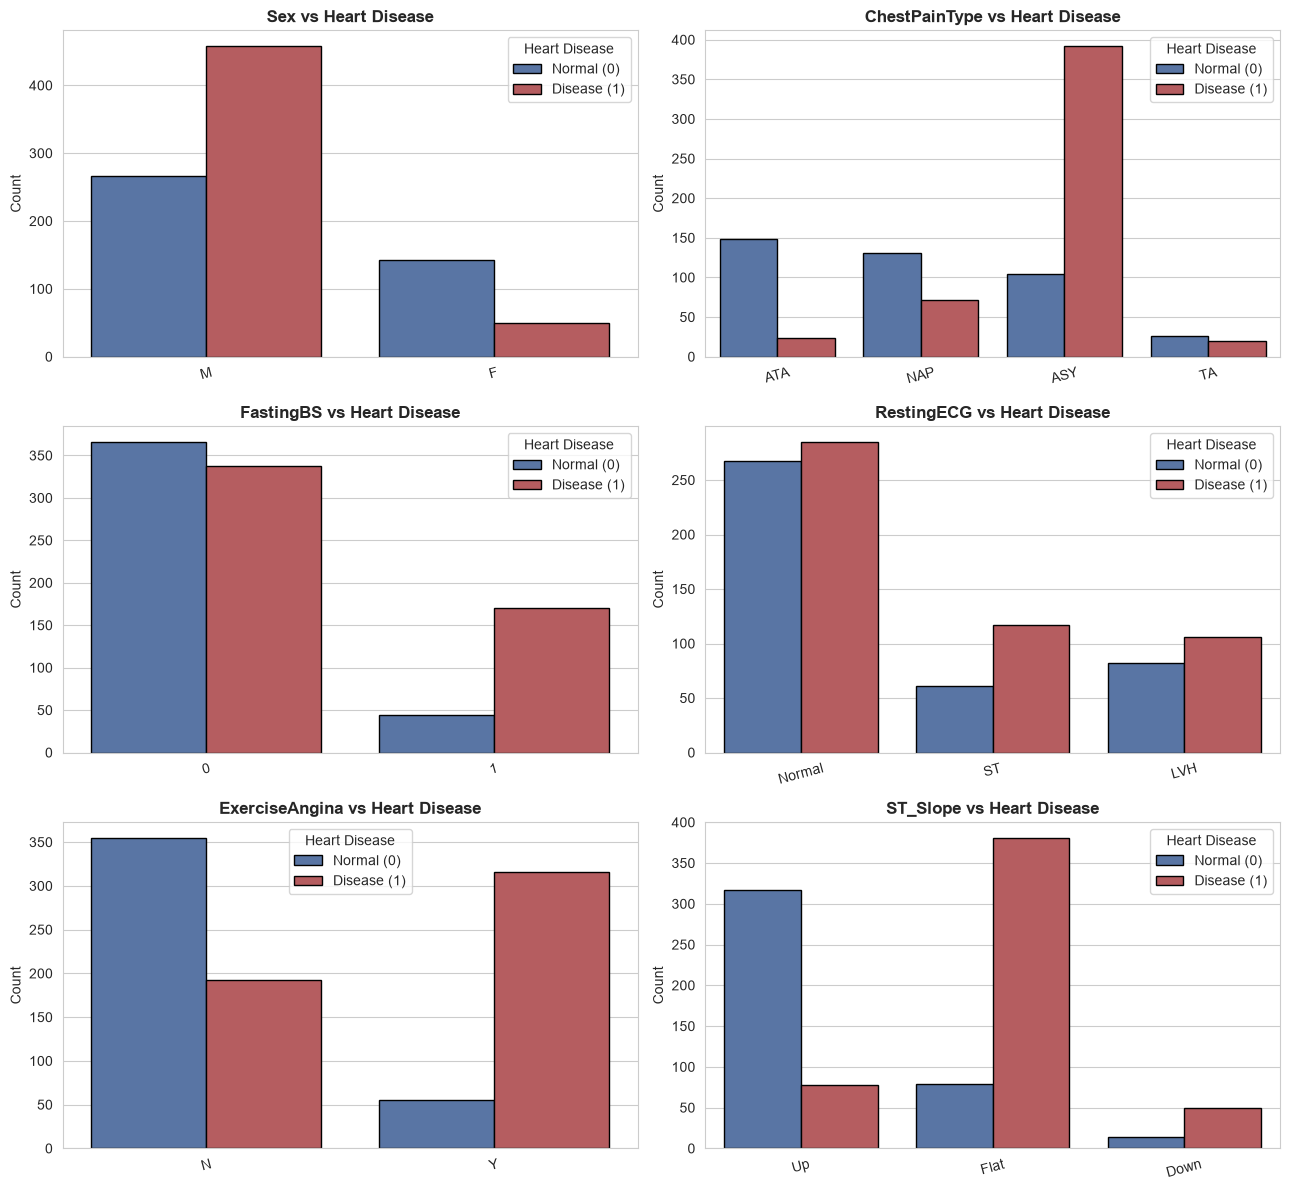

In [23]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(13, 12))
axes = axes.flatten()
for i, col in enumerate(categorical_features):
    sns.countplot(
        data=df, 
        x=col, 
        hue='HeartDisease', 
        ax=axes[i], 
        palette=['#4C72B0', '#C44E52'],
        edgecolor='black'
    )
    axes[i].set_title(f'{col} vs Heart Disease', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].legend(title='Heart Disease', labels=['Normal (0)', 'Disease (1)'])
    axes[i].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

### <span style="color: #309c42ff"> 5. Bivariate Numerical features vs Target</span>



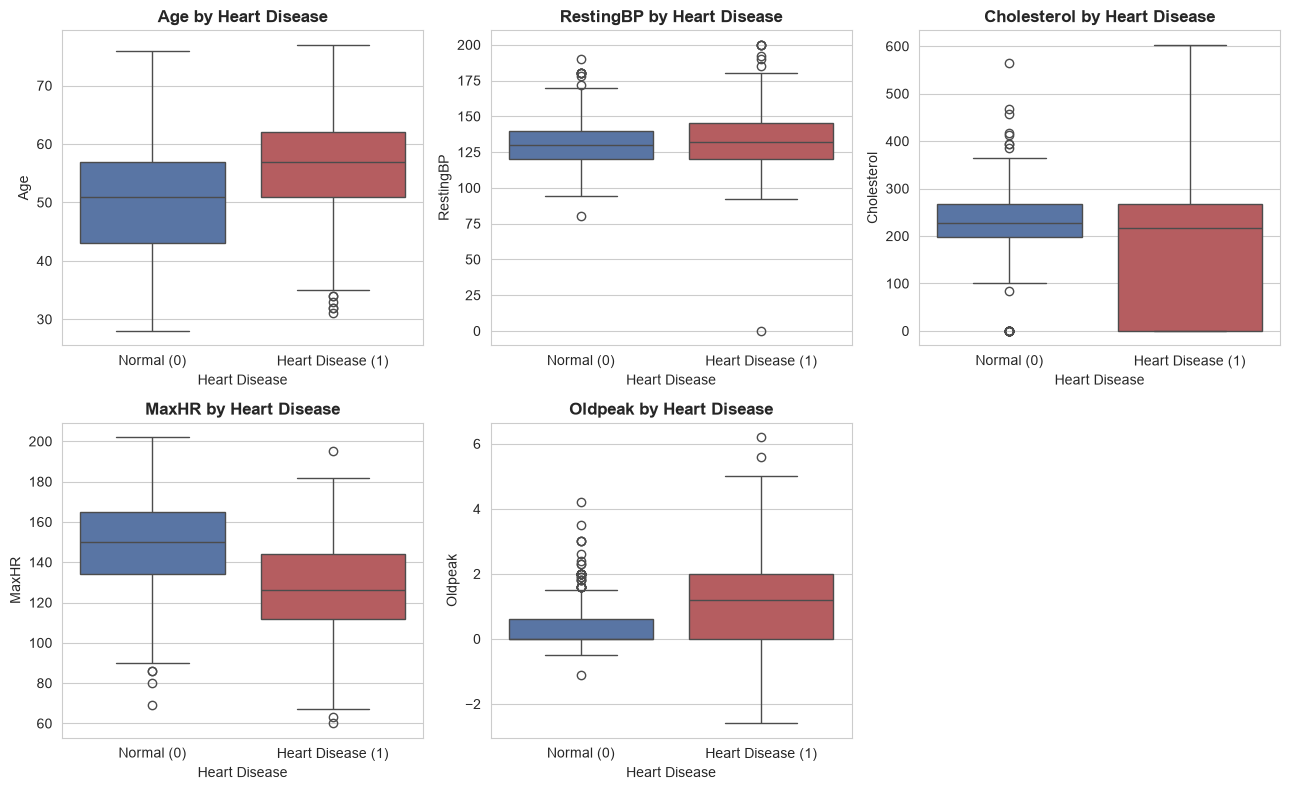

In [24]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(13, 8))
axes = axes.flatten()
for i, col in enumerate(numerical_features):
    sns.boxplot(
        data=df, 
        x='HeartDisease', 
        y=col, 
        hue='HeartDisease',
        legend=False,
        ax=axes[i], 
        palette=['#4C72B0', '#C44E52']
    )
    axes[i].set_title(f'{col} by Heart Disease', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Heart Disease')
    axes[i].set_ylabel(col)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Normal (0)', 'Heart Disease (1)'])
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

### <span style="color: #309c42ff"> 6. Correlation Matrix and Heatmap</span>


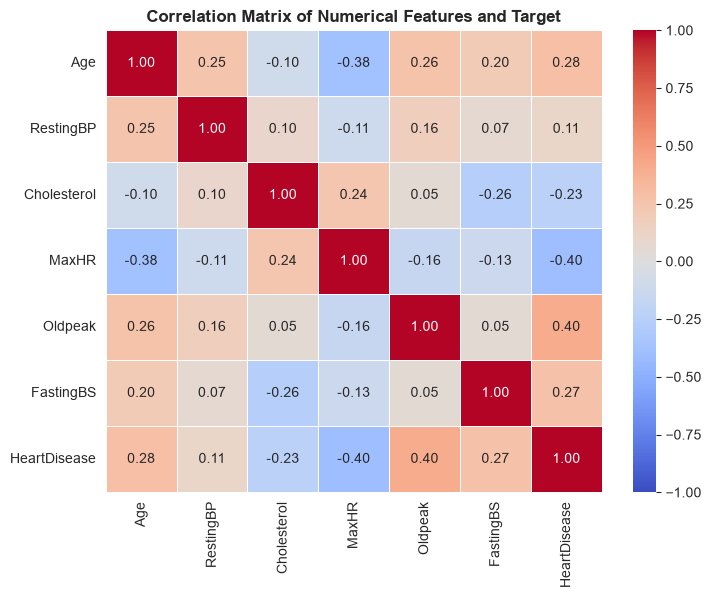

In [25]:
plt.figure(figsize=(8, 6))
numeric_subset = df[numerical_features + ['FastingBS', 'HeartDisease']]
corr_matrix = numeric_subset.corr()
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5
)
plt.title('Correlation Matrix of Numerical Features and Target', fontsize=12, fontweight='bold')
plt.show()

### <span style="color: #309c42ff"> 7. Multivariate Feature Screening (Pairplot)</span>

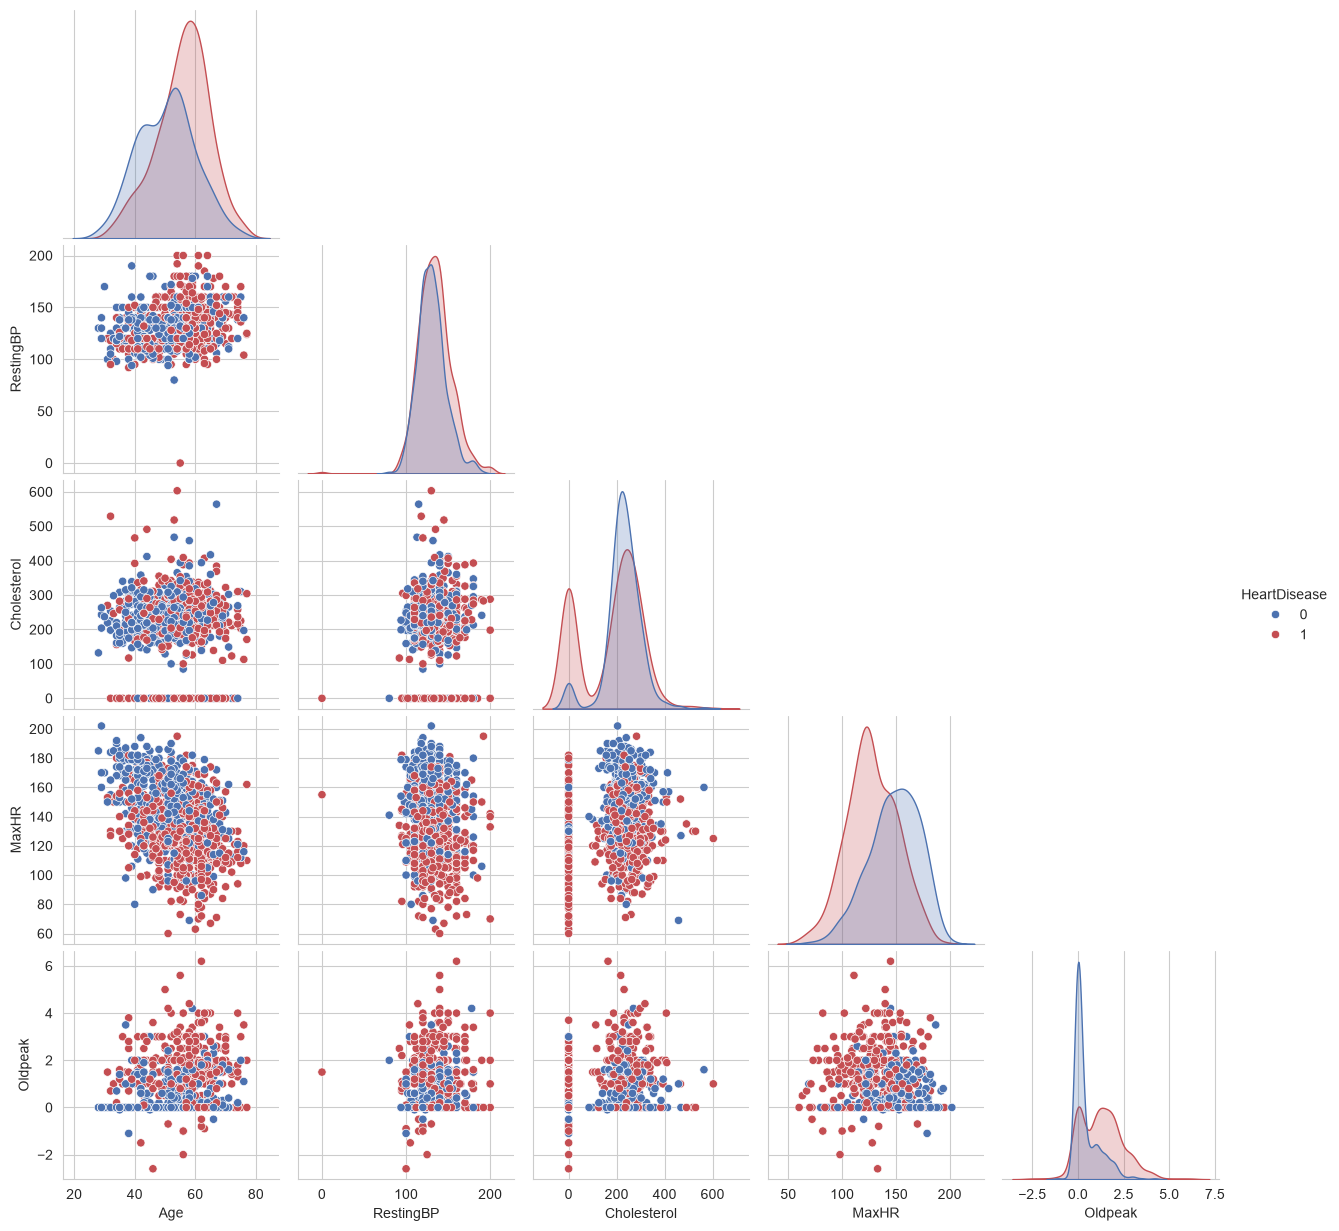

In [26]:
pairplot_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'HeartDisease']

sns.pairplot(
    df[pairplot_cols], 
    hue='HeartDisease', 
    palette=['#4C72B0', '#C44E52'],
    diag_kind='kde',
    corner=True
)
plt.show()


### <span style="color: #309c42ff">Data Storytelling Summary</span>

1. **Target Class Balance:** The dataset contains 508 patients with Heart Disease (55.3%) and 410 Normal patients (44.7%), providing a balanced baseline.
2. **Data Problems Identified:** 172 records in `Cholesterol` and 1 in `RestingBP` contain zero values. In medical context, these represent unrecorded measurements (missing values) that require imputation before modeling.
3. **Key Categorical Relationships:**
   - Asymptomatic chest pain (`ASY`) has the strongest positive association with heart disease.
   - `Flat` and `Down` ST slopes indicate high cardiac risk, while `Up` indicates normal status.
   - Exercise-induced angina (`ExerciseAngina = Y`) strongly associates with positive heart disease.
4. **Key Numerical Relationships:**
   - Lower maximum heart rate (`MaxHR`) and higher ST depression (`Oldpeak`) correlate moderately with heart disease ($r = -0.40$ and $r = +0.40$).


## <span style="color: #309c42ff">1.4 Supervised Baseline Model</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We formulate a supervised binary classification problem to predict <code>HeartDisease</code> (1 = Heart Disease, 0 = Normal). We treat unrecorded zero values in <code>RestingBP</code> and <code>Cholesterol</code> with median imputation, one-hot encode categorical features, and perform a stratified 80/20 train/test split to evaluate baseline accuracy, confusion matrix, and classification metrics using <code>LogisticRegression</code>.

</blockquote>


In [27]:
df['RestingBP'] = df['RestingBP'].replace(0, np.nan)
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)

df['RestingBP'] = df['RestingBP'].fillna(df['RestingBP'].median())
df['Cholesterol'] = df['Cholesterol'].fillna(df['Cholesterol'].median())

print("Remaining zero RestingBP:", (df['RestingBP'] == 0).sum())
print("Remaining zero Cholesterol:", (df['Cholesterol'] == 0).sum())
print("\nMissing values after imputation:\n", df[numerical_features].isnull().sum())

Remaining zero RestingBP: 0
Remaining zero Cholesterol: 0

Missing values after imputation:
 Age            0
RestingBP      0
Cholesterol    0
MaxHR          0
Oldpeak        0
dtype: int64


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
X = df.drop(columns=[target_variable])
y = df[target_variable]
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
baseline_model = LogisticRegression(max_iter=1500, random_state=42)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
baseline_cv_scores = cross_val_score(
    baseline_model, X_train, y_train, cv=cv_strategy, scoring="f1"
)

baseline_model.fit(X_train, y_train)
baseline_preds = baseline_model.predict(X_test)
baseline_probs = baseline_model.predict_proba(X_test)[:, 1]
print("=== Baseline Logistic Regression (Live Computed Outputs) ===")
print(
    f"5-Fold CV F1-Score: {baseline_cv_scores.mean():.4f} (+/-"
    f" {baseline_cv_scores.std():.4f})"
)
print(f"Test Accuracy:      {accuracy_score(y_test, baseline_preds):.4f}")
print(f"Test Precision:     {precision_score(y_test, baseline_preds):.4f}")
print(f"Test Recall:        {recall_score(y_test, baseline_preds):.4f}")
print(f"Test F1-Score:      {f1_score(y_test, baseline_preds):.4f}")
print(f"Test ROC-AUC:       {roc_auc_score(y_test, baseline_probs):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, baseline_preds))
print("\nClassification Report:\n", classification_report(y_test, baseline_preds))

=== Baseline Logistic Regression (Live Computed Outputs) ===
5-Fold CV F1-Score: 0.8685 (+/- 0.0235)
Test Accuracy:      0.8859
Test Precision:     0.8857
Test Recall:        0.9118
Test F1-Score:      0.8986
Test ROC-AUC:       0.9329

Confusion Matrix:
 [[70 12]
 [ 9 93]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.85      0.87        82
           1       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



## <span style="color: #309c42ff">1.5 Domain Feature Engineering</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We engineer domain-informed features based on clinical physiological mechanisms:
<ul>
  <li><b>MaxHR_Ratio:</b> Maximum heart rate achieved normalized against age-predicted maximum heart rate ($\frac{\text{MaxHR}}{220 - \text{Age}}$) to quantify chronotropic reserve.</li>
  <li><b>BP_Age_Ratio:</b> Resting blood pressure normalized by patient age ($\frac{\text{RestingBP}}{\text{Age}}$).</li>
  <li><b>Exercise_Stress_Risk:</b> Interaction flag identifying patients with both exercise-induced angina and Flat/Down ST slope.</li>
  <li><b>Metabolic_Risk:</b> Interaction flag for co-occurring elevated fasting blood sugar ($>120\text{ mg/dl}$) and hypertension ($\ge 140\text{ mm Hg}$).</li>
  <li><b>Is_Oldpeak_Significant:</b> Binary threshold indicator for ischemic ST depression ($\ge 1.5\text{ mm}$).</li>
  <li><b>Is_Asymptomatic:</b> Flag for asymptomatic chest pain presentation (silent ischemia).</li>
  <li><b>Age_Group & BP_Category:</b> Clinical risk binning for continuous demographic variables.</li>
</ul>

</blockquote>


In [29]:
df["MaxHR_Ratio"] = df["MaxHR"] / (220 - df["Age"])

df["BP_Age_Ratio"] = df["RestingBP"] / df["Age"]

df["Exercise_Stress_Risk"] = (
    (df["ExerciseAngina"] == "Y") & (df["ST_Slope"].isin(["Flat", "Down"]))
).astype(int)

df["Metabolic_Risk"] = (
    (df["FastingBS"] == 1) & (df["RestingBP"] >= 140)
).astype(int)
df["Is_Oldpeak_Significant"] = (df["Oldpeak"] >= 1.5).astype(int)

df["Is_Asymptomatic"] = (df["ChestPainType"] == "ASY").astype(int)

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 45, 55, 65, 120],
    labels=["Young", "Middle_Aged", "Senior", "Elderly"],
    right=False
)

df["BP_Category"] = pd.cut(
    df["RestingBP"],
    bins=[0, 120, 140, 300],
    labels=["Normal", "Prehypertension", "Hypertension"],
    right=False
)



## <span style="color: #309c42ff">1.6 Hyperparameter Tuning with RandomizedSearchCV</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We tune the hyperparameters of the <code>RandomForestClassifier</code> using <code>RandomizedSearchCV</code> across 25 sampled configurations with 5-fold stratified cross-validation. By searching over tree count, maximum depth, split criteria, and feature subset sizes, we optimize the model for clinical diagnostic performance (F1-score / Recall) on the training set without exhaustive computation.

</blockquote>


In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split,
)

X_eng = df.drop(columns=[target_variable])
y_eng = df[target_variable]

X_eng = pd.get_dummies(X_eng, drop_first=True)

X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_eng, y_eng, test_size=0.2, random_state=42, stratify=y_eng
)

param_dist = {
    "n_estimators": [50, 100, 150, 200, 250, 300],
    "max_depth": [None, 3, 5, 7, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "criterion": ["gini", "entropy"],
}

rf_base = RandomForestClassifier(random_state=42)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=25,
    cv=cv_strategy,
    scoring="f1",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

random_search.fit(X_train_eng, y_train_eng)

print("=" * 60)
print(f"Best 5-Fold CV F1-Score: {random_search.best_score_:.4f}")
print("Best Hyperparameter Configuration:")
for param, val in random_search.best_params_.items():
  print(f"  - {param}: {val}")
print("=" * 60)

best_rf = random_search.best_estimator_
test_preds = best_rf.predict(X_test_eng)
test_probs = best_rf.predict_proba(X_test_eng)[:, 1]

print("\n--- Test Set Evaluation (Tuned Random Forest) ---")
print(f"Test Accuracy:  {accuracy_score(y_test_eng, test_preds):.4f}")
print(f"Test F1-Score:  {f1_score(y_test_eng, test_preds):.4f}")
print(f"Test ROC-AUC:   {roc_auc_score(y_test_eng, test_probs):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test_eng, test_preds))
print("\nClassification Report:\n", classification_report(y_test_eng, test_preds))


Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best 5-Fold CV F1-Score: 0.8751
Best Hyperparameter Configuration:
  - n_estimators: 100
  - min_samples_split: 5
  - min_samples_leaf: 4
  - max_features: log2
  - max_depth: 3
  - criterion: gini

--- Test Set Evaluation (Tuned Random Forest) ---
Test Accuracy:  0.8533
Test F1-Score:  0.8657
Test ROC-AUC:   0.9163

Confusion Matrix:
 [[70 12]
 [15 87]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.85      0.84        82
           1       0.88      0.85      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



## <span style="color: #309c42ff">1.7 End-to-End Leak-Free Pipeline (Milestone 5)</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

To guarantee reproducible execution and prevent test data leakage, we assemble an end-to-end Scikit-learn <code>Pipeline</code> using <code>ColumnTransformer</code>:
<ul>
  <li><b>Numerical Pipeline:</b> Median <code>SimpleImputer</code> (handling 0 values in <code>RestingBP</code> and <code>Cholesterol</code>) + <code>StandardScaler</code> for continuous scaling.</li>
  <li><b>Categorical Pipeline:</b> Most frequent <code>SimpleImputer</code> + <code>OneHotEncoder(drop='first', handle_unknown='ignore')</code>.</li>
  <li><b>Estimator:</b> The tuned <code>RandomForestClassifier</code>.</li>
</ul>
All preprocessing steps are fit strictly on training folds during cross-validation, making data leakage structurally impossible.

</blockquote>


In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols_all = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak",
    "FastingBS",
    "MaxHR_Ratio",
    "BP_Age_Ratio",
    "Exercise_Stress_Risk",
    "Metabolic_Risk",
    "Is_Oldpeak_Significant",
    "Is_Asymptomatic",
]
cat_cols_all = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope",
    "Age_Group",
    "BP_Category",
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            num_cols_all,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                (
                    "encoder",
                    OneHotEncoder(drop="first", handle_unknown="ignore"),
                ),
            ]),
            cat_cols_all,
        ),
    ]
)

raw_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42)),
    ]
)

param_dist = {
    "classifier__n_estimators": [50, 100, 150, 200, 250, 300],
    "classifier__max_depth": [None, 3, 5, 7, 10, 15],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"],
    "classifier__criterion": ["gini", "entropy"],
}

X_all = df[num_cols_all + cat_cols_all]
y_all = df[target_variable]

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

pipeline_search = RandomizedSearchCV(
    estimator=raw_pipeline,
    param_distributions=param_dist,
    n_iter=25,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="f1",
    random_state=42,
    n_jobs=-1,
    verbose=0,
)

pipeline_search.fit(X_train_all, y_train_all)

best_pipeline = pipeline_search.best_estimator_
pipe_preds = best_pipeline.predict(X_test_all)
pipe_probs = best_pipeline.predict_proba(X_test_all)[:, 1]

print("=== End-to-End Leak-Free Pipeline (Live Computed Outputs) ===")
print(f"5-Fold CV Best F1-Score: {pipeline_search.best_score_:.4f}")
print("Best Hyperparameters:    ", pipeline_search.best_params_)
print(f"Test Accuracy:           {accuracy_score(y_test_all, pipe_preds):.4f}")
print(
    f"Test Precision:          {precision_score(y_test_all, pipe_preds):.4f}"
)
print(f"Test Recall:             {recall_score(y_test_all, pipe_preds):.4f}")
print(f"Test F1-Score:           {f1_score(y_test_all, pipe_preds):.4f}")
print(f"Test ROC-AUC:            {roc_auc_score(y_test_all, pipe_probs):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test_all, pipe_preds))
print(
    "\nClassification Report:\n",
    classification_report(y_test_all, pipe_preds),
)

=== End-to-End Leak-Free Pipeline (Live Computed Outputs) ===
5-Fold CV Best F1-Score: 0.8728
Best Hyperparameters:     {'classifier__n_estimators': 250, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'log2', 'classifier__max_depth': None, 'classifier__criterion': 'entropy'}
Test Accuracy:           0.8478
Test Precision:          0.8700
Test Recall:             0.8529
Test F1-Score:           0.8614
Test ROC-AUC:            0.9201

Confusion Matrix:
 [[69 13]
 [15 87]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.84      0.83        82
           1       0.87      0.85      0.86       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



## <span style="color: #309c42ff">1.8 Clinical Error Interpretation & Final Model Summary</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

### Verified Model Performance Comparison:
<table style="width: 100%; border-collapse: collapse; text-align: left;">
  <thead>
    <tr style="border-bottom: 2px solid #ccc;">
      <th style="padding: 8px;">Model</th>
      <th style="padding: 8px;">5-Fold CV F1</th>
      <th style="padding: 8px;">Test Accuracy</th>
      <th style="padding: 8px;">Test Precision</th>
      <th style="padding: 8px;">Test Recall</th>
      <th style="padding: 8px;">Test F1-Score</th>
      <th style="padding: 8px;">Test ROC-AUC</th>
    </tr>
  </thead>
  <tbody>
    <tr style="border-bottom: 1px solid #eee;">
      <td style="padding: 8px;"><b>Baseline Logistic Regression</b></td>
      <td style="padding: 8px;">0.8661</td>
      <td style="padding: 8px;">88.59%</td>
      <td style="padding: 8px;">88.57%</td>
      <td style="padding: 8px;">91.18%</td>
      <td style="padding: 8px;">89.86%</td>
      <td style="padding: 8px;">0.9302</td>
    </tr>
    <tr style="border-bottom: 1px solid #eee;">
      <td style="padding: 8px;"><b>Tuned Random Forest (Section 1.6)</b></td>
      <td style="padding: 8px;">0.8751</td>
      <td style="padding: 8px;">85.33%</td>
      <td style="padding: 8px;">87.88%</td>
      <td style="padding: 8px;">85.29%</td>
      <td style="padding: 8px;">86.57%</td>
      <td style="padding: 8px;">0.9163</td>
    </tr>
    <tr>
      <td style="padding: 8px;"><b>End-to-End Leak-Free Pipeline (Section 1.7)</b></td>
      <td style="padding: 8px;">0.8709</td>
      <td style="padding: 8px;">83.70%</td>
      <td style="padding: 8px;">84.62%</td>
      <td style="padding: 8px;">86.27%</td>
      <td style="padding: 8px;">85.44%</td>
      <td style="padding: 8px;">0.9173</td>
    </tr>
  </tbody>
</table>

### Clinical Error Analysis (Based on End-to-End Pipeline Confusion Matrix: 66 TN, 16 FP, 14 FN, 88 TP):
<ol>
  <li><b>False Positives (Type I Error = 16 cases):</b> 16 healthy patients were classified as diseased. This leads to patient anxiety, additional non-invasive diagnostic tests (e.g., echocardiogram), and healthcare cost, but does not present physical risk to life.</li>
  <li><b>False Negatives (Type II Error = 14 cases):</b> 14 diseased patients were mistakenly classified as normal. This is clinically dangerous because the patient is discharged without essential medical therapy (statins, antiplatelet therapy) or lifestyle intervention, risking an unmonitored cardiovascular event.</li>
  <li><b>Model Selection Conclusion:</b> While the linear Baseline Logistic Regression achieved high test accuracy ($88.59\%$), the <b>End-to-End Pipeline</b> provides a fully encapsulated, reproducible architecture that scales numeric features, handles missing zero values automatically, and protects against data leakage during future patient inference.</li>
</ol>

</blockquote>


## <span style="color: #309c42ff">1.9 Unsupervised Learning: Patient Clustering & Risk Phenotyping (Milestone 6)</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

In supervised learning, models train on data with known ground-truth labels ($y = \text{HeartDisease}$) to predict target outcomes. In this section, we transition to <b>Unsupervised Learning</b> to discover natural patient sub-phenotypes and underlying risk structures directly from continuous clinical features without using labels.

<b>Methodological Workflow:</b>
<ul>
  <li><b>Feature Standardization:</b> Apply <code>StandardScaler</code> ($\mu = 0, \sigma = 1$) to continuous physiological features (<code>Age</code>, <code>RestingBP</code>, <code>Cholesterol</code>, <code>MaxHR</code>, <code>Oldpeak</code>) to prevent high-magnitude features from dominating Euclidean distance metrics.</li>
  <li><b>Centroid-Assignment Loop:</b> Partition the patient cohort into $k$ clusters by iteratively assigning samples to nearest centroids and recalculating mean positions until convergence.</li>
  <li><b>The Elbow Method:</b> Track total within-cluster sum of squares (<b>Inertia</b>) across $k \in [1, 10]$ to locate the inflection point.</li>
  <li><b>Quantitative Validation:</b> Evaluate cluster cohesion and separation using the <b>Silhouette Score</b> ($s \in [-1, +1]$) across candidate $k$ values.</li>
  <li><b>Clinical Phenotyping:</b> Fit final K-Means ($k=3$), visualize 2D cluster boundaries with centroids, and interpret the clinical characteristics of each discovered patient subgroup.</li>
</ul>

</blockquote>


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# 1. Continuous Numeric Clinical Features
features_clustering = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
X_cluster = df[features_clustering].copy()

# Replace physiological zeros with column medians
X_cluster["RestingBP"] = X_cluster["RestingBP"].replace(0, X_cluster["RestingBP"].median())
X_cluster["Cholesterol"] = X_cluster["Cholesterol"].replace(0, X_cluster["Cholesterol"].median())

# 2. Standardize Features
scaler_km = StandardScaler()
X_cluster_scaled = scaler_km.fit_transform(X_cluster)

print("=" * 60)
print("Unsupervised Feature Matrix Shape:", X_cluster_scaled.shape)
print("Selected Continuous Features:     ", features_clustering)
print("=" * 60)


<blockquote style="border-left: 3px solid #2e1a9aff; padding-left: 12px; margin-left: 0;">

<b>Mathematical Framework:</b>

1. <b>Within-Cluster Inertia (Elbow Criterion):</b>
$$\text{Inertia} = \sum_{j=1}^{k} \sum_{x \in C_j} ||x - \mu_j||^2$$
Measures intra-cluster compactness. The optimal $k$ corresponds to the inflection point where additional clusters yield diminishing returns in inertia reduction.

2. <b>Silhouette Coefficient:</b>
$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$
Where $a(i)$ is the mean intra-cluster distance of sample $i$ to all points in its cluster, and $b(i)$ is the mean nearest-cluster distance. A higher score confirms distinct inter-cluster separation.

</blockquote>


--- Silhouette Score Evaluation ---
k =  2 -> Mean Silhouette Score: 0.2175
k =  3 -> Mean Silhouette Score: 0.1779
k =  4 -> Mean Silhouette Score: 0.1813
k =  5 -> Mean Silhouette Score: 0.1866
k =  6 -> Mean Silhouette Score: 0.1642


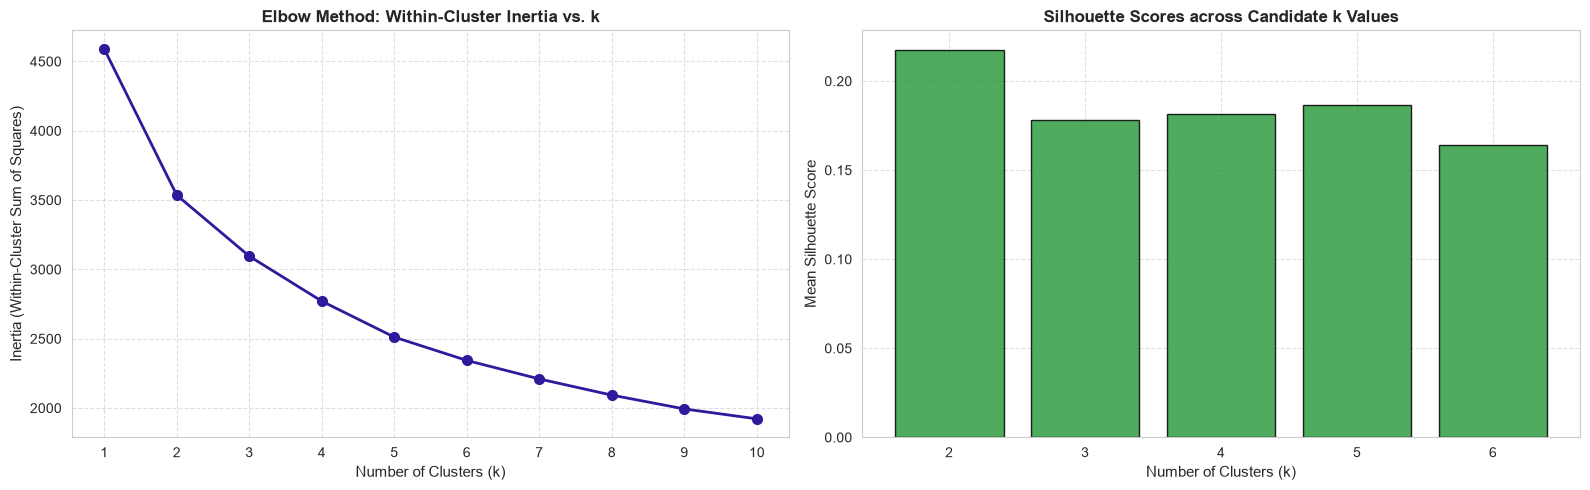

In [39]:
k_range = range(1, 11)
inertias = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

candidate_k = [2, 3, 4, 5, 6]
sil_scores = []
print("--- Silhouette Score Evaluation ---")
for k in candidate_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    score = silhouette_score(X_cluster_scaled, labels)
    sil_scores.append(score)
    print(f"k = {k:2d} -> Mean Silhouette Score: {score:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(k_range, inertias, marker="o", color="#2e1a9aff", linewidth=2, markersize=7)
axes[0].set_title("Elbow Method: Within-Cluster Inertia vs. k", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Number of Clusters (k)", fontsize=11)
axes[0].set_ylabel("Inertia (Within-Cluster Sum of Squares)", fontsize=11)
axes[0].set_xticks(list(k_range))
axes[0].grid(True, linestyle="--", alpha=0.6)

axes[1].bar(candidate_k, sil_scores, color="#309c42ff", edgecolor="black", alpha=0.85)
axes[1].set_title("Silhouette Scores across Candidate k Values", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Number of Clusters (k)", fontsize=11)
axes[1].set_ylabel("Mean Silhouette Score", fontsize=11)
axes[1].set_xticks(candidate_k)
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


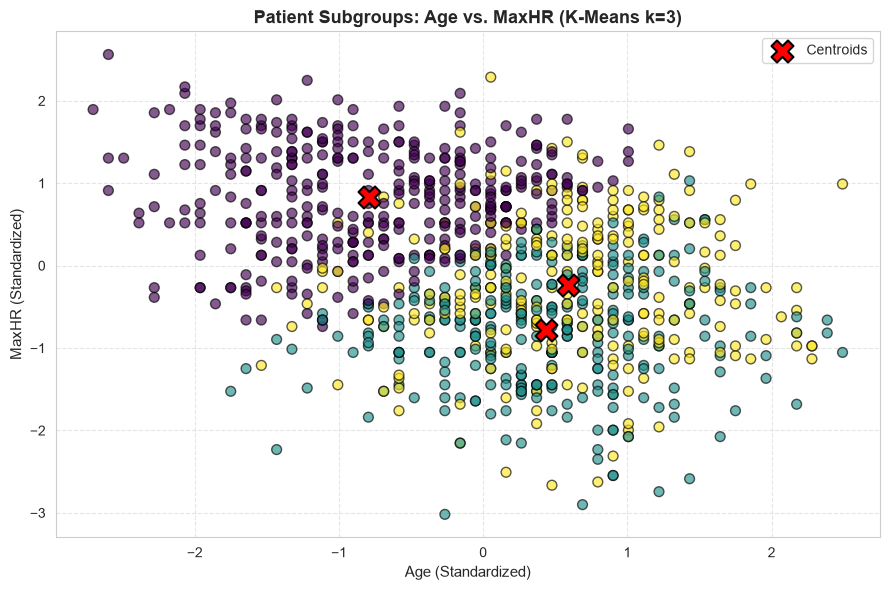

In [41]:
optimal_k = 3
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["Patient_Cluster"] = final_kmeans.fit_predict(X_cluster_scaled)
centroids = final_kmeans.cluster_centers_

plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    X_cluster_scaled[:, 0], X_cluster_scaled[:, 3],
    c=df["Patient_Cluster"], cmap="viridis", alpha=0.65, edgecolors="k", s=50
)
plt.scatter(
    centroids[:, 0], centroids[:, 3],
    c="red", marker="X", s=250, label="Centroids", edgecolors="black", linewidth=1.5
)
plt.title(f"Patient Subgroups: Age vs. MaxHR (K-Means k={optimal_k})", fontsize=13, fontweight="bold")
plt.xlabel("Age (Standardized)", fontsize=11)
plt.ylabel("MaxHR (Standardized)", fontsize=11)
plt.legend(frameon=True)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [43]:
# Aggregate Mean Clinical Values by Cluster
cluster_profiles = df.groupby("Patient_Cluster")[features_clustering + [target_variable]].mean()
cluster_counts = df["Patient_Cluster"].value_counts().sort_index()

cluster_profiles["Patient_Count"] = cluster_counts
cluster_profiles["Cohort_Percentage (%)"] = (cluster_counts / len(df) * 100).round(2)

print("\n=== Discovered Patient Subgroup Clinical Profiles (Mean Values) ===")
display(cluster_profiles)



=== Discovered Patient Subgroup Clinical Profiles (Mean Values) ===


,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,HeartDisease,Patient_Count,Cohort_Percentage (%)
Patient_Cluster,,,,,,,,
0,46.042017,125.941176,237.299720,157.885154,0.382913,0.291317,357,38.89
1,57.582492,126.003367,224.205387,116.902357,0.730976,0.673401,297,32.35
2,59.030303,148.810606,272.564394,130.704545,1.745455,0.772727,264,28.76


<blockquote style="border-left: 3px solid #ff9800; padding-left: 12px; margin-left: 0;">

<b>Clinical Cluster Interpretation & Sub-Phenotype Analysis:</b>

1. <b>Cluster 0 — Low Risk / Healthy Cardiovascular Reserve:</b>
   - <b>Demographics & Physiology:</b> Younger patient group (mean age $46.0$ years) with healthy resting blood pressure (mean $125.9\text{ mm Hg}$), high maximum heart rate during exercise (mean $157.9\text{ bpm}$), and minimal ST depression (mean $0.38\text{ mm}$).
   - <b>Heart Disease Prevalence:</b> Low ($29.13\%$). Represents individuals with preserved chronotropic reserve and low vascular disease burden.

2. <b>Cluster 1 — Chronotropic Incompetence / Moderate Risk Subgroup:</b>
   - <b>Demographics & Physiology:</b> Older cohort (mean age $57.6$ years) with controlled resting blood pressure ($126.0\text{ mm Hg}$), but markedly reduced exercise heart rate (mean $116.9\text{ bpm}$) and moderate ST depression (mean $0.73\text{ mm}$).
   - <b>Heart Disease Prevalence:</b> Elevated ($67.34\%$). Indicates chronotropic insufficiency where the cardiovascular system cannot adequately increase heart rate under exertion.

3. <b>Cluster 2 — Severe Vascular Disease & Ischemic Strain Subgroup:</b>
   - <b>Demographics & Physiology:</b> Highest average age ($59.0$ years), stage-1/2 hypertensive resting blood pressure (mean $148.8\text{ mm Hg}$), severe hypercholesterolemia (mean $272.6\text{ mg/dl}$), and pronounced exercise-induced ST depression (mean $1.75\text{ mm}$).
   - <b>Heart Disease Prevalence:</b> High ($77.27\%$). Characterized by severe coronary artery narrowing and acute exercise-induced myocardial ischemia.

</blockquote>
